# Data Quality and Preparation

## Objective

This part prepares the banking data before deeper analysis. I am checking whether the raw files are usable, connected correctly, and clean enough for customer portfolio and lending-risk work.

Main outputs from this part:

- clean customer-level data
- clean loan-level data
- validation summaries
- data dictionary
- saved tables and charts for later use

No prediction model is built here. This step is only for cleaning, validation, and preparing the final datasets.



## 1. Import Libraries and Locate Folders

This section loads Python libraries and finds the project folders. I keep this code simple so a beginner can understand where the data is coming from and where outputs are saved.


In [1]:
# Basic libraries used in this notebook
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="darkgrid", palette="deep")

# Find project folders automatically.
# This lets the notebook run from either the project root or the notebooks folder.
cwd = Path.cwd().resolve()
project_root = cwd
while project_root != project_root.parent and not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
tables_dir = project_root / "reports" / "tables"
figures_dir = project_root / "reports" / "figures"

# Create output folders if they do not already exist.
for folder in [processed_dir, tables_dir, figures_dir / "data_quality"]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Raw folder:", raw_dir)


Project root: C:\tmp\Data_Analytics_publish_fresh\Projects\banking-customer-analytics
Raw folder: C:\tmp\Data_Analytics_publish_fresh\Projects\banking-customer-analytics\data\raw


### Paths Used

The raw data, processed data, tables, and figures are stored in fixed project folders. This keeps the outputs easy to find and rerun.



## 2. Load the Raw Dataset Files

The new dataset is split into four clear business tables:

- `customers.csv`: customer profile and relationship information
- `financial_profile.csv`: deposits, savings, credit card usage, and debt burden
- `loans.csv`: loan product, amount, term, interest rate, and collateral
- `loan_risk.csv`: credit score, DTI, LTV, missed payments, repayment status, default flag, and expected loss


In [2]:
# Load each raw CSV file.
customers = pd.read_csv(raw_dir / "customers.csv")
financial = pd.read_csv(raw_dir / "financial_profile.csv")
loans = pd.read_csv(raw_dir / "loans.csv")
risk = pd.read_csv(raw_dir / "loan_risk.csv")

# Create a small table so we can quickly see dataset size.
raw_file_summary = pd.DataFrame({
    "file_name": ["customers.csv", "financial_profile.csv", "loans.csv", "loan_risk.csv"],
    "business_level": ["One row per customer", "One row per customer", "One row per loan", "One row per loan"],
    "rows": [len(customers), len(financial), len(loans), len(risk)],
    "columns": [customers.shape[1], financial.shape[1], loans.shape[1], risk.shape[1]],
})

raw_file_summary


,file_name,business_level,rows,columns
0,customers.csv,One row per customer,15000,15
1,financial_profile.csv,One row per customer,15000,12
2,loans.csv,One row per loan,11911,11
3,loan_risk.csv,One row per loan,11911,10


### File Structure Check

There are two customer-level files and two loan-level files:

- customer profile and bank relationship data
- financial balance data
- loan details
- loan risk and repayment data

This structure keeps the data organized while still allowing joins through IDs.



## 3. Preview Each Raw Table

Before cleaning anything, I inspect the first few rows and column names. This helps confirm that the dataset contains the information required for the business problem.


In [3]:
raw_tables = {
    "customers": customers,
    "financial_profile": financial,
    "loans": loans,
    "loan_risk": risk,
}

for table_name, table in raw_tables.items():
    print(f"\n{table_name.upper()} TABLE")
    print(f"Rows: {table.shape[0]:,} | Columns: {table.shape[1]:,}")
    print("Columns:", list(table.columns))
    display(table.head(3))



CUSTOMERS TABLE
Rows: 15,000 | Columns: 15
Columns: ['customer_id', 'customer_name', 'age', 'gender', 'nationality', 'occupation', 'employment_status', 'city', 'state', 'banking_relationship', 'loyalty_classification', 'fee_structure', 'investment_advisor', 'joined_bank', 'annual_income']


,customer_id,customer_name,age,gender,nationality,occupation,employment_status,city,state,banking_relationship,loyalty_classification,fee_structure,investment_advisor,joined_bank,annual_income
0,CUST00001,Vivaan Coleman,39,Male,Indian,Software Engineer,Salaried,Bengaluru,Rajasthan,Commercial,Silver,Standard,Advisor D,2012-11-27,"622,998.69"
1,CUST00002,Ayaan Sharma,46,Male,Indian,Teacher,NaN,Chennai,Karnataka,Retail,Jade,Standard,Advisor F,2018-05-27,"656,347.95"
2,CUST00003,Aanya Khan,53,Female,Indian,Software Engineer,Self Employed,Bengaluru,Uttar Pradesh,Commercial,Jade,Standard,Advisor C,2005-05-09,"762,539.30"



FINANCIAL_PROFILE TABLE
Rows: 15,000 | Columns: 12
Columns: ['customer_id', 'monthly_income', 'bank_deposits', 'checking_balance', 'savings_balance', 'credit_card_limit', 'credit_card_balance', 'credit_utilization_ratio', 'business_lending', 'existing_monthly_debt_payment', 'total_deposit_balance', 'deposit_to_income_ratio']


,customer_id,monthly_income,bank_deposits,checking_balance,savings_balance,credit_card_limit,credit_card_balance,credit_utilization_ratio,business_lending,existing_monthly_debt_payment,total_deposit_balance,deposit_to_income_ratio
0,CUST00001,"51,916.56","1,365,784.88","173,758.24","790,230.17","207,711.53","6,690.19",0.03,"743,025.13","23,011.36","2,329,773.29",3.74
1,CUST00002,"54,695.66","1,232,480.83","58,494.62","552,113.34","46,628.12","6,594.13",0.14,"43,596.49","16,395.37","1,843,088.79",2.81
2,CUST00003,"63,544.94","1,198,496.17","223,448.02","761,389.46","135,795.38","7,493.89",0.06,"1,074,104.35","16,676.04","2,183,333.65",2.86



LOANS TABLE
Rows: 11,911 | Columns: 11
Columns: ['loan_id', 'customer_id', 'loan_type', 'loan_amount', 'loan_term_months', 'interest_rate', 'loan_start_date', 'collateral_type', 'collateral_value', 'monthly_loan_payment', 'loan_purpose']


,loan_id,customer_id,loan_type,loan_amount,loan_term_months,interest_rate,loan_start_date,collateral_type,collateral_value,monthly_loan_payment,loan_purpose
0,LOAN000001,CUST07874,Education Loan,"476,245.49",67,9.82,2023-08-14,Unsecured,0.00,"9,262.29",Higher Education
1,LOAN000002,CUST05835,Home Loan,"2,900,138.60",248,9.86,2021-08-08,Property,"4,143,693.51","27,434.77",Home Purchase
2,LOAN000003,CUST09330,Home Loan,"1,647,702.57",249,7.60,2021-05-21,Property,"2,622,794.55","13,169.82",Home Purchase



LOAN_RISK TABLE
Rows: 11,911 | Columns: 10
Columns: ['loan_id', 'credit_score', 'debt_to_income_ratio', 'loan_to_value_ratio', 'missed_payments_12m', 'days_past_due', 'repayment_status', 'default_flag', 'risk_band', 'expected_loss_amount']


,loan_id,credit_score,debt_to_income_ratio,loan_to_value_ratio,missed_payments_12m,days_past_due,repayment_status,default_flag,risk_band,expected_loss_amount
0,LOAN000001,701.00,0.44,NaN,0,0,Current,0,Low,"11,667.54"
1,LOAN000002,690.00,0.76,0.70,2,48,Current,0,Medium,"113,222.50"
2,LOAN000003,684.00,0.63,0.63,0,0,Current,0,Low,"41,793.69"


### Raw Fields Available

The raw tables include the fields needed for the analysis:

- customer profile: age, gender, occupation, income, relationship type
- financial position: deposits, savings, card balance, existing debt
- loan profile: loan amount, term, rate, collateral, purpose
- risk outcome: credit score, DTI, LTV, missed payments, repayment status, default flag

These fields are enough to study borrower profile, portfolio exposure, and repayment risk.



## 4. Clean Realistic Raw-Data Imperfections

The raw dataset now intentionally includes realistic banking-data imperfections, such as missing income, missing credit scores, inconsistent text casing, extra spaces, missing interest rates, and paid-off/write-off repayment labels.

This section cleans only the issues that should be cleaned before analysis. Logical missing values, such as missing LTV for unsecured loans, are kept because they carry business meaning.



In [4]:
# First, record raw missing values before cleaning.
raw_missing_summary = pd.DataFrame([
    {"table": "customers", "column": "annual_income", "missing_before": customers["annual_income"].isna().sum()},
    {"table": "customers", "column": "occupation", "missing_before": customers["occupation"].isna().sum()},
    {"table": "customers", "column": "employment_status", "missing_before": customers["employment_status"].isna().sum()},
    {"table": "financial_profile", "column": "credit_utilization_ratio", "missing_before": financial["credit_utilization_ratio"].isna().sum()},
    {"table": "financial_profile", "column": "savings_balance", "missing_before": financial["savings_balance"].isna().sum()},
    {"table": "financial_profile", "column": "checking_balance", "missing_before": financial["checking_balance"].isna().sum()},
    {"table": "loans", "column": "interest_rate", "missing_before": loans["interest_rate"].isna().sum()},
    {"table": "loan_risk", "column": "credit_score", "missing_before": risk["credit_score"].isna().sum()},
    {"table": "loan_risk", "column": "debt_to_income_ratio", "missing_before": risk["debt_to_income_ratio"].isna().sum()},
])

raw_missing_summary

,table,column,missing_before
0,customers,annual_income,225
1,customers,occupation,150
2,customers,employment_status,120
3,financial_profile,credit_utilization_ratio,180
4,financial_profile,savings_balance,90
5,financial_profile,checking_balance,60
6,loans,interest_rate,95
7,loan_risk,credit_score,214
8,loan_risk,debt_to_income_ratio,119


In [5]:
# Check messy raw category labels before cleaning.
raw_category_examples = pd.DataFrame([
    {"column": "banking_relationship", "raw_unique_values": customers["banking_relationship"].nunique(), "sample_values": customers["banking_relationship"].dropna().unique()[:8].tolist()},
    {"column": "loyalty_classification", "raw_unique_values": customers["loyalty_classification"].nunique(), "sample_values": customers["loyalty_classification"].dropna().unique()[:8].tolist()},
    {"column": "loan_type", "raw_unique_values": loans["loan_type"].nunique(), "sample_values": loans["loan_type"].dropna().unique()[:8].tolist()},
    {"column": "repayment_status", "raw_unique_values": risk["repayment_status"].nunique(), "sample_values": risk["repayment_status"].dropna().unique()[:10].tolist()},
    {"column": "risk_band", "raw_unique_values": risk["risk_band"].nunique(), "sample_values": risk["risk_band"].dropna().unique()[:8].tolist()},
])
raw_category_examples



,column,raw_unique_values,sample_values
0,banking_relationship,24,"[Commercial, Retail, Private Bank, Institution..."
1,loyalty_classification,24,"[Silver, Jade, Gold, Platinum, Jade , silver..."
2,loan_type,30,"[Education Loan, Home Loan, Business Loan, Aut..."
3,repayment_status,32,"[Current, Paid Off, Defaulted, Late, Written O..."
4,risk_band,18,"[Low, Medium, High, Low , LOW, HIGH, MEDIUM ..."


In [6]:
# Helper function for cleaning repeated text labels.
def clean_text_label(series):
    return series.astype("string").str.strip().str.replace(r"\s+", " ", regex=True).str.title()

# Clean customer text fields.
for column in ["gender", "nationality", "occupation", "employment_status", "city", "state", "banking_relationship", "loyalty_classification", "fee_structure", "investment_advisor"]:
    customers[column] = clean_text_label(customers[column])

# Fix known title-case side effects and missing categories.
customers["banking_relationship"] = customers["banking_relationship"].replace({"Private Bank": "Private Bank"})
customers["occupation"] = customers["occupation"].fillna("Unknown")
customers["employment_status"] = customers["employment_status"].fillna("Unknown")

# Recover missing annual income from monthly income where possible.
monthly_income_lookup = financial.set_index("customer_id")["monthly_income"]
missing_income_mask = customers["annual_income"].isna()
customers.loc[missing_income_mask, "annual_income"] = (
    customers.loc[missing_income_mask, "customer_id"].map(monthly_income_lookup) * 12
).round(2)

# If any income is still missing, use the median income by relationship segment.
customers["annual_income"] = customers.groupby("banking_relationship", observed=False)["annual_income"].transform(
    lambda values: values.fillna(values.median())
)

# Clean loan and risk labels.
loans["loan_type"] = clean_text_label(loans["loan_type"])
loans["collateral_type"] = clean_text_label(loans["collateral_type"])
loans["loan_purpose"] = clean_text_label(loans["loan_purpose"])
risk["repayment_status"] = clean_text_label(risk["repayment_status"])
risk["repayment_status"] = risk["repayment_status"].replace({"Written Off": "Written Off"})
risk["risk_band"] = clean_text_label(risk["risk_band"])

# Repair missing account balances using conservative median imputation.
for column in ["checking_balance", "savings_balance"]:
    financial[column] = financial[column].fillna(financial[column].median())

# Recalculate derived balances after repairing missing account balances.
financial["total_deposit_balance"] = (
    financial["bank_deposits"] + financial["checking_balance"] + financial["savings_balance"]
).round(2)

# Repair missing credit utilization ratio from balance and limit.
util_missing_mask = financial["credit_utilization_ratio"].isna()
financial.loc[util_missing_mask, "credit_utilization_ratio"] = (
    financial.loc[util_missing_mask, "credit_card_balance"] / financial.loc[util_missing_mask, "credit_card_limit"]
).round(3)

# Repair missing interest rates using median interest rate by loan type.
loans["interest_rate"] = loans.groupby("loan_type", observed=False)["interest_rate"].transform(
    lambda values: values.fillna(values.median())
)

# Repair model-important risk fields using segment medians.
risk["credit_score"] = risk.groupby("risk_band", observed=False)["credit_score"].transform(
    lambda values: values.fillna(values.median())
)
risk["debt_to_income_ratio"] = risk.groupby("risk_band", observed=False)["debt_to_income_ratio"].transform(
    lambda values: values.fillna(values.median())
)

# Recalculate deposit-to-income ratio after income repair.
income_lookup = customers.set_index("customer_id")["annual_income"]
financial["deposit_to_income_ratio"] = (
    financial["total_deposit_balance"] / financial["customer_id"].map(income_lookup)
).round(3)

cleaning_actions = pd.DataFrame([
    {"issue": "inconsistent text labels", "action": "stripped spaces and standardized casing"},
    {"issue": "missing annual income", "action": "recovered from monthly income or relationship median"},
    {"issue": "missing occupation/employment", "action": "filled with Unknown"},
    {"issue": "missing checking/savings balances", "action": "filled with median balance"},
    {"issue": "missing credit utilization", "action": "recomputed from card balance and limit"},
    {"issue": "missing interest rate", "action": "filled with loan-type median"},
    {"issue": "missing credit score and DTI", "action": "filled with risk-band median"},
    {"issue": "missing LTV for unsecured loans", "action": "kept as logical missing value"},
])

cleaning_actions

,issue,action
0,inconsistent text labels,stripped spaces and standardized casing
1,missing annual income,recovered from monthly income or relationship ...
2,missing occupation/employment,filled with Unknown
3,missing checking/savings balances,filled with median balance
4,missing credit utilization,recomputed from card balance and limit
5,missing interest rate,filled with loan-type median
6,missing credit score and DTI,filled with risk-band median
7,missing LTV for unsecured loans,kept as logical missing value


In [7]:
# Check missing values after cleaning for fields that should be model-ready.
cleaned_missing_summary = pd.DataFrame([
    {"table": "customers", "column": "annual_income", "missing_after": customers["annual_income"].isna().sum()},
    {"table": "customers", "column": "occupation", "missing_after": customers["occupation"].isna().sum()},
    {"table": "customers", "column": "employment_status", "missing_after": customers["employment_status"].isna().sum()},
    {"table": "financial_profile", "column": "credit_utilization_ratio", "missing_after": financial["credit_utilization_ratio"].isna().sum()},
    {"table": "financial_profile", "column": "savings_balance", "missing_after": financial["savings_balance"].isna().sum()},
    {"table": "financial_profile", "column": "checking_balance", "missing_after": financial["checking_balance"].isna().sum()},
    {"table": "loans", "column": "interest_rate", "missing_after": loans["interest_rate"].isna().sum()},
    {"table": "loan_risk", "column": "credit_score", "missing_after": risk["credit_score"].isna().sum()},
    {"table": "loan_risk", "column": "debt_to_income_ratio", "missing_after": risk["debt_to_income_ratio"].isna().sum()},
])

raw_vs_clean_missing = raw_missing_summary.merge(
    cleaned_missing_summary,
    on=["table", "column"],
    how="left"
)
raw_vs_clean_missing

,table,column,missing_before,missing_after
0,customers,annual_income,225,0
1,customers,occupation,150,0
2,customers,employment_status,120,0
3,financial_profile,credit_utilization_ratio,180,0
4,financial_profile,savings_balance,90,0
5,financial_profile,checking_balance,60,0
6,loans,interest_rate,95,0
7,loan_risk,credit_score,214,0
8,loan_risk,debt_to_income_ratio,119,0


### Cleaning Result

The raw data has realistic issues, but the important analysis fields are repaired here. I keep collateral and LTV missing where they are not applicable, mainly for unsecured loans.



## 5. Validate Primary Keys and Relationships

This is the most important data-quality check. If IDs are broken, the analysis will be unreliable.

We check:

- customer IDs are unique where they should be unique
- loan IDs are unique where they should be unique
- every financial profile belongs to a real customer
- every loan belongs to a real customer
- every loan has a matching risk record


In [8]:
validation_checks = pd.DataFrame([
    {
        "check": "customer_id is unique in customers",
        "result": customers["customer_id"].is_unique,
        "why_it_matters": "Each customer should appear once in the customer master table."
    },
    {
        "check": "customer_id is unique in financial_profile",
        "result": financial["customer_id"].is_unique,
        "why_it_matters": "Each customer should have one financial profile."
    },
    {
        "check": "loan_id is unique in loans",
        "result": loans["loan_id"].is_unique,
        "why_it_matters": "Each loan should appear once in the loan table."
    },
    {
        "check": "loan_id is unique in loan_risk",
        "result": risk["loan_id"].is_unique,
        "why_it_matters": "Each loan should have one risk/outcome record."
    },
    {
        "check": "all financial customers exist in customers",
        "result": financial["customer_id"].isin(customers["customer_id"]).all(),
        "why_it_matters": "Financial rows should not point to unknown customers."
    },
    {
        "check": "all loan customers exist in customers",
        "result": loans["customer_id"].isin(customers["customer_id"]).all(),
        "why_it_matters": "Loans should not belong to unknown customers."
    },
    {
        "check": "all loans have risk records",
        "result": loans["loan_id"].isin(risk["loan_id"]).all(),
        "why_it_matters": "Every loan needs repayment/risk information for this project."
    },
])

validation_checks["status"] = validation_checks["result"].map({True: "PASS", False: "FAIL"})
validation_checks[["check", "status", "why_it_matters"]]


,check,status,why_it_matters
0,customer_id is unique in customers,PASS,Each customer should appear once in the custom...
1,customer_id is unique in financial_profile,PASS,Each customer should have one financial profile.
2,loan_id is unique in loans,PASS,Each loan should appear once in the loan table.
3,loan_id is unique in loan_risk,PASS,Each loan should have one risk/outcome record.
4,all financial customers exist in customers,PASS,Financial rows should not point to unknown cus...
5,all loan customers exist in customers,PASS,Loans should not belong to unknown customers.
6,all loans have risk records,PASS,Every loan needs repayment/risk information fo...


In [9]:
# A simple final pass/fail flag for the whole section.
all_relationship_checks_passed = validation_checks["result"].all()
print("All ID and relationship checks passed:", all_relationship_checks_passed)


All ID and relationship checks passed: True


### Relationship Check Result

The key joins are valid. Customer profile, financial position, loan details, and repayment outcome can be connected correctly through `customer_id` and `loan_id`.



## 6. Create Analysis-Ready Tables

I create two clean tables:

1. `customer_profile`: one row per customer, used for customer portfolio and segment analysis.
2. `loan_analysis`: one row per loan, used for exposure, repayment, and default-risk analysis.


In [10]:
# Customer-level table: customer profile + financial position
customer_profile = customers.merge(
    financial,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

# Loan-level table: loan details + risk outcome + customer profile + financial position
loan_analysis = (
    loans.merge(risk, on="loan_id", how="inner", validate="one_to_one")
    .merge(customers, on="customer_id", how="left", validate="many_to_one")
    .merge(financial, on="customer_id", how="left", validate="many_to_one")
)

merge_summary = pd.DataFrame([
    {"dataset": "customer_profile", "level": "one row per customer", "rows": len(customer_profile), "columns": customer_profile.shape[1]},
    {"dataset": "loan_analysis", "level": "one row per loan", "rows": len(loan_analysis), "columns": loan_analysis.shape[1]},
])
merge_summary


,dataset,level,rows,columns
0,customer_profile,one row per customer,15000,26
1,loan_analysis,one row per loan,11911,45


In [11]:
# Important portfolio counts after merging
portfolio_base_summary = pd.DataFrame([
    {"metric": "total customers", "value": len(customer_profile)},
    {"metric": "total loan records", "value": len(loan_analysis)},
    {"metric": "customers with at least one loan", "value": loan_analysis["customer_id"].nunique()},
    {"metric": "customers without loans", "value": len(customer_profile) - loan_analysis["customer_id"].nunique()},
    {"metric": "overall default rate percent", "value": round(loan_analysis["default_flag"].mean() * 100, 2)},
])
portfolio_base_summary


,metric,value
0,total customers,"15,000.00"
1,total loan records,"11,911.00"
2,customers with at least one loan,"10,279.00"
3,customers without loans,"4,721.00"
4,overall default rate percent,12.41


### Merged Data Result

The merge creates two useful views:

- customer-level data for customer portfolio analysis
- loan-level data for lending exposure and repayment-risk analysis

The merged loan data also gives the final default rate and the number of customers with active loan records.



## 7. Fix Data Types

Dates should be dates, and category-like columns should be treated as categories. This makes grouping, plotting, and time-based analysis cleaner.


In [12]:
# Convert date columns into proper datetime format.
for frame in [customer_profile, loan_analysis]:
    for date_column in ["joined_bank", "loan_start_date"]:
        if date_column in frame.columns:
            frame[date_column] = pd.to_datetime(frame[date_column], errors="coerce")

# Convert repeated text fields into category type.
category_columns = [
    "gender", "nationality", "occupation", "employment_status", "city", "state",
    "banking_relationship", "loyalty_classification", "fee_structure", "investment_advisor",
    "loan_type", "collateral_type", "loan_purpose", "repayment_status", "risk_band",
]

for frame in [customer_profile, loan_analysis]:
    for column in category_columns:
        if column in frame.columns:
            frame[column] = frame[column].astype("category")

# Show only the important converted columns.
dtype_summary = pd.DataFrame({
    "column": ["joined_bank", "loan_start_date", "banking_relationship", "loan_type", "repayment_status", "risk_band"],
    "loan_analysis_dtype": [str(loan_analysis[col].dtype) if col in loan_analysis.columns else "not available" for col in ["joined_bank", "loan_start_date", "banking_relationship", "loan_type", "repayment_status", "risk_band"]]
})
dtype_summary


,column,loan_analysis_dtype
0,joined_bank,datetime64[ns]
1,loan_start_date,datetime64[ns]
2,banking_relationship,category
3,loan_type,category
4,repayment_status,category
5,risk_band,category


### Date and Category Result

Date columns are converted to real datetime values, and repeated category labels are standardized. This avoids errors while grouping by dates, segments, loan types, and repayment status.



## 8. Feature Engineering

Feature engineering means creating useful analysis columns from existing fields.

These new columns help answer business questions like:

- Which age/income groups are customers in?
- Is credit utilization low or high?
- Is DTI safe or risky?
- Is LTV safe or risky?
- Does a customer have recent delinquency?


In [13]:
analysis_date = pd.Timestamp("2026-07-24")

# Customer-level features
age_bins = [17, 25, 35, 45, 55, 65, 100]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]

income_bins = [0, 400000, 800000, 1500000, 3000000, float("inf")]
income_labels = ["Low", "Lower Middle", "Middle", "High", "Affluent"]

util_bins = [-0.01, 0.30, 0.60, 0.85, 1.01]
util_labels = ["Low", "Moderate", "High", "Maxed"]

for frame in [customer_profile, loan_analysis]:
    frame["age_group"] = pd.cut(frame["age"], bins=age_bins, labels=age_labels)
    frame["income_band"] = pd.cut(frame["annual_income"], bins=income_bins, labels=income_labels)
    frame["customer_tenure_years"] = ((analysis_date - frame["joined_bank"]).dt.days / 365.25).round(1)
    frame["credit_utilization_band"] = pd.cut(frame["credit_utilization_ratio"], bins=util_bins, labels=util_labels)

# Loan-level risk features
loan_analysis["credit_score_band"] = pd.cut(
    loan_analysis["credit_score"],
    bins=[299, 579, 669, 739, 799, 850],
    labels=["Poor", "Fair", "Good", "Very Good", "Excellent"]
)

loan_analysis["dti_band"] = pd.cut(
    loan_analysis["debt_to_income_ratio"],
    bins=[0, 0.35, 0.45, 0.60, 2],
    labels=["<=35%", "35-45%", "45-60%", ">60%"]
)

loan_analysis["ltv_band"] = pd.cut(
    loan_analysis["loan_to_value_ratio"],
    bins=[0, 0.60, 0.80, 0.95, 2],
    labels=["<=60%", "60-80%", "80-95%", ">95%"]
)

loan_analysis["has_recent_delinquency"] = (
    loan_analysis["missed_payments_12m"].gt(0) |
    loan_analysis["days_past_due"].gt(0)
)

loan_analysis["loan_to_income_ratio"] = (loan_analysis["loan_amount"] / loan_analysis["annual_income"]).round(2)
loan_analysis["exposure_after_deposits"] = (loan_analysis["loan_amount"] - loan_analysis["total_deposit_balance"]).clip(lower=0)

engineered_columns = [
    "age_group", "income_band", "customer_tenure_years", "credit_utilization_band",
    "credit_score_band", "dti_band", "ltv_band", "has_recent_delinquency",
    "loan_to_income_ratio", "exposure_after_deposits"
]

loan_analysis[["customer_id", "loan_id"] + engineered_columns].head()


,customer_id,loan_id,age_group,income_band,customer_tenure_years,credit_utilization_band,credit_score_band,dti_band,ltv_band,has_recent_delinquency,loan_to_income_ratio,exposure_after_deposits
0,CUST07874,LOAN000001,18-25,Middle,25.90,Moderate,Good,35-45%,NaN,False,0.46,0.00
1,CUST05835,LOAN000002,46-55,Lower Middle,19.00,Low,Good,>60%,60-80%,True,4.02,"1,631,459.84"
2,CUST09330,LOAN000003,36-45,Lower Middle,25.00,Low,Good,>60%,60-80%,False,3.39,0.00
3,CUST03418,LOAN000004,36-45,Middle,16.90,Low,Good,>60%,NaN,False,2.87,0.00
4,CUST07800,LOAN000005,46-55,Lower Middle,4.40,Moderate,Good,45-60%,80-95%,False,0.39,0.00


In [14]:
# Show the distribution of important engineered risk fields.
engineered_result_summary = pd.DataFrame({
    "feature": ["income_band", "dti_band", "credit_score_band", "risk_band", "has_recent_delinquency"],
    "non_missing_values": [
        loan_analysis["income_band"].notna().sum(),
        loan_analysis["dti_band"].notna().sum(),
        loan_analysis["credit_score_band"].notna().sum(),
        loan_analysis["risk_band"].notna().sum(),
        loan_analysis["has_recent_delinquency"].notna().sum(),
    ],
    "missing_values": [
        loan_analysis["income_band"].isna().sum(),
        loan_analysis["dti_band"].isna().sum(),
        loan_analysis["credit_score_band"].isna().sum(),
        loan_analysis["risk_band"].isna().sum(),
        loan_analysis["has_recent_delinquency"].isna().sum(),
    ],
})
engineered_result_summary


,feature,non_missing_values,missing_values
0,income_band,11911,0
1,dti_band,11911,0
2,credit_score_band,11911,0
3,risk_band,11911,0
4,has_recent_delinquency,11911,0


### Feature Engineering Result

The new fields make the data easier to analyze. For example, `dti_band` helps compare default rates for low-debt borrowers versus over-leveraged borrowers. These fields can also be reused later for modelling.



## 9. Missing Values, Duplicates, and Valid Ranges

This section checks whether the cleaned datasets have problems that could make the analysis misleading.


In [15]:
# Missing values in the final loan-level table
missing_summary = loan_analysis.isna().sum().rename("missing_count").to_frame()
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(loan_analysis) * 100).round(2)
missing_summary = missing_summary.query("missing_count > 0").sort_values("missing_pct", ascending=False)

# Duplicate checks
duplicate_summary = pd.DataFrame([
    {"check": "duplicate customer IDs in customer_profile", "count": int(customer_profile["customer_id"].duplicated().sum())},
    {"check": "duplicate loan IDs in loan_analysis", "count": int(loan_analysis["loan_id"].duplicated().sum())},
    {"check": "exact duplicate customer rows", "count": int(customer_profile.duplicated().sum())},
    {"check": "exact duplicate loan rows", "count": int(loan_analysis.duplicated().sum())},
])

# Business range checks
range_checks = pd.DataFrame([
    {"check": "age is between 18 and 80", "result": customer_profile["age"].between(18, 80).all()},
    {"check": "annual income is positive", "result": customer_profile["annual_income"].gt(0).all()},
    {"check": "loan amount is positive", "result": loan_analysis["loan_amount"].gt(0).all()},
    {"check": "credit score is between 300 and 850", "result": loan_analysis["credit_score"].between(300, 850).all()},
    {"check": "default_flag contains only 0 and 1", "result": set(loan_analysis["default_flag"].unique()).issubset({0, 1})},
])
range_checks["status"] = range_checks["result"].map({True: "PASS", False: "FAIL"})

print("Missing values found in these columns:")
display(missing_summary)
print("Duplicate check result:")
display(duplicate_summary)
print("Range check result:")
display(range_checks[["check", "status"]])


Missing values found in these columns:


,missing_count,missing_pct
loan_to_value_ratio,3324,27.91
ltv_band,3324,27.91


Duplicate check result:


,check,count
0,duplicate customer IDs in customer_profile,0
1,duplicate loan IDs in loan_analysis,0
2,exact duplicate customer rows,0
3,exact duplicate loan rows,0


Range check result:


,check,status
0,age is between 18 and 80,PASS
1,annual income is positive,PASS
2,loan amount is positive,PASS
3,credit score is between 300 and 850,PASS
4,default_flag contains only 0 and 1,PASS


### Quality Check Result

The important ID and duplicate checks are clean. Remaining missing values need business interpretation, especially collateral-related fields where unsecured loans naturally do not have collateral.



## 10. Outlier Analysis with IQR and Boxplots

Real financial data usually has outliers. I check outliers, but I do not remove them automatically because high income, large loans, high deposits, and high expected loss can be valid banking cases.

Here I use the IQR method and boxplots to identify unusual values for review.


In [16]:
# Calculate IQR outliers for important numeric columns.
def calculate_iqr_outliers(data, column):
    values = data[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    outlier_count = ((values < lower_limit) | (values > upper_limit)).sum()
    return {
        "column": column,
        "q1": round(q1, 2),
        "median": round(values.median(), 2),
        "q3": round(q3, 2),
        "lower_limit": round(lower_limit, 2),
        "upper_limit": round(upper_limit, 2),
        "min_value": round(values.min(), 2),
        "max_value": round(values.max(), 2),
        "outlier_count": int(outlier_count),
        "outlier_pct": round(outlier_count / len(values) * 100, 2),
    }

outlier_columns = [
    "annual_income",
    "total_deposit_balance",
    "loan_amount",
    "credit_score",
    "debt_to_income_ratio",
    "expected_loss_amount",
]

outlier_summary = pd.DataFrame([
    calculate_iqr_outliers(loan_analysis, column)
    for column in outlier_columns
])

outlier_summary



,column,q1,median,q3,lower_limit,upper_limit,min_value,max_value,outlier_count,outlier_pct
0,annual_income,"612,107.65","874,386.72","1,236,603.08","-324,635.49","2,173,346.21","180,000.00","7,701,302.64",494,4.15
1,total_deposit_balance,"1,469,987.28","2,352,189.40","3,789,238.84","-2,008,890.06","7,268,116.18","270,313.59","25,447,052.25",676,5.68
2,loan_amount,"412,325.52","1,242,368.33","2,969,437.58","-3,423,342.58","6,805,105.68","47,812.40","18,000,000.00",548,4.60
3,credit_score,645.00,674.00,702.00,559.50,787.50,540.00,826.00,73,0.61
4,debt_to_income_ratio,0.41,0.57,0.74,-0.09,1.24,0.05,1.35,140,1.18
5,expected_loss_amount,"9,162.55","39,994.74","162,308.61","-220,556.53","392,027.69",432.06,"6,681,004.38",1376,11.55


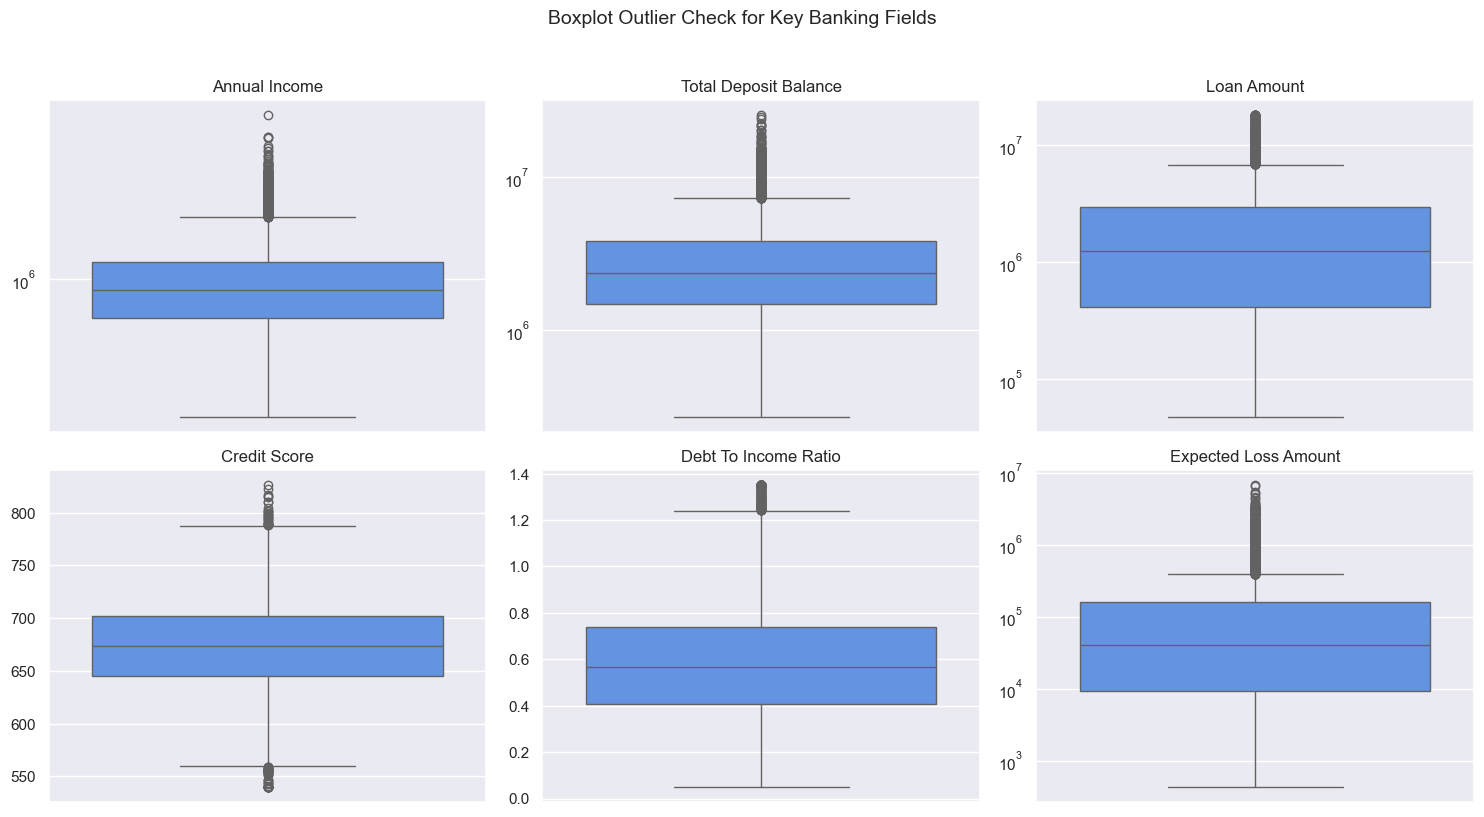

In [17]:
# Boxplots for key numeric fields.
outlier_figures_dir = figures_dir / "data_quality"
outlier_figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for index, column in enumerate(outlier_columns):
    sns.boxplot(y=loan_analysis[column], ax=axes[index], color="#4f8ef7")
    axes[index].set_title(column.replace("_", " ").title())
    axes[index].set_xlabel("")
    axes[index].set_ylabel("")
    if column in ["annual_income", "total_deposit_balance", "loan_amount", "expected_loss_amount"]:
        axes[index].set_yscale("log")

fig.suptitle("Boxplot Outlier Check for Key Banking Fields", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(outlier_figures_dir / "outlier_boxplots.png", dpi=160, bbox_inches="tight")
plt.show()



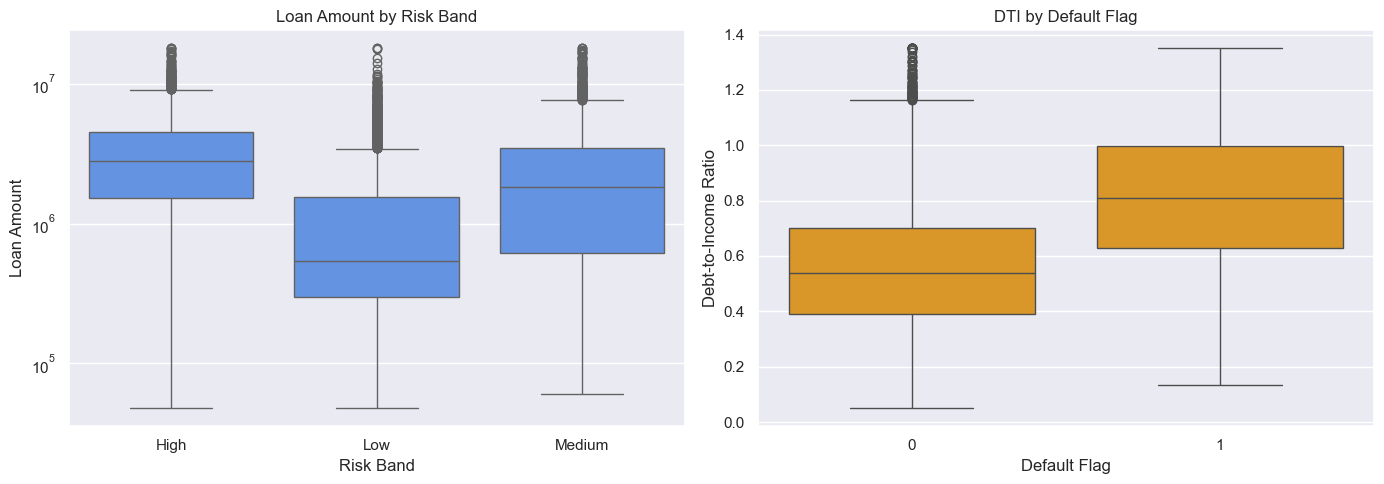

In [18]:
# Business-focused boxplots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=loan_analysis, x="risk_band", y="loan_amount", ax=axes[0], color="#4f8ef7")
axes[0].set_title("Loan Amount by Risk Band")
axes[0].set_xlabel("Risk Band")
axes[0].set_ylabel("Loan Amount")
axes[0].set_yscale("log")

sns.boxplot(data=loan_analysis, x="default_flag", y="debt_to_income_ratio", ax=axes[1], color="#f59e0b")
axes[1].set_title("DTI by Default Flag")
axes[1].set_xlabel("Default Flag")
axes[1].set_ylabel("Debt-to-Income Ratio")

fig.tight_layout()
fig.savefig(outlier_figures_dir / "business_outlier_boxplots.png", dpi=160, bbox_inches="tight")
plt.show()



### Outlier Result

The boxplots show outliers in financial fields, which is expected in banking data. I keep them because large loans, high-income customers, and high expected-loss accounts are important for portfolio-risk analysis.



## 11. Key Portfolio Quality Results

After cleaning, I checked a few important portfolio numbers to confirm that the prepared data is useful for risk and exposure analysis.



In [19]:
quality_insight_summary = pd.DataFrame([
    {"insight": "Customer base prepared", "value": f"{len(customer_profile):,} customers"},
    {"insight": "Loan portfolio prepared", "value": f"{len(loan_analysis):,} loan records"},
    {"insight": "Customers with loans", "value": f"{loan_analysis['customer_id'].nunique():,} customers"},
    {"insight": "Overall default rate", "value": f"{loan_analysis['default_flag'].mean() * 100:.2f}%"},
    {"insight": "Total loan exposure", "value": f"INR {loan_analysis['loan_amount'].sum() / 10_000_000:.2f} crore"},
    {"insight": "Total expected loss", "value": f"INR {loan_analysis['expected_loss_amount'].sum() / 10_000_000:.2f} crore"},
    {"insight": "Highest DTI band default rate", "value": f"{loan_analysis.groupby('dti_band', observed=False)['default_flag'].mean().max() * 100:.2f}%"},
    {"insight": "High risk band default rate", "value": f"{loan_analysis.loc[loan_analysis['risk_band'].eq('High'), 'default_flag'].mean() * 100:.2f}%"},
])
quality_insight_summary


,insight,value
0,Customer base prepared,"15,000 customers"
1,Loan portfolio prepared,"11,911 loan records"
2,Customers with loans,"10,279 customers"
3,Overall default rate,12.41%
4,Total loan exposure,INR 2460.72 crore
5,Total expected loss,INR 199.17 crore
6,Highest DTI band default rate,21.78%
7,High risk band default rate,53.82%


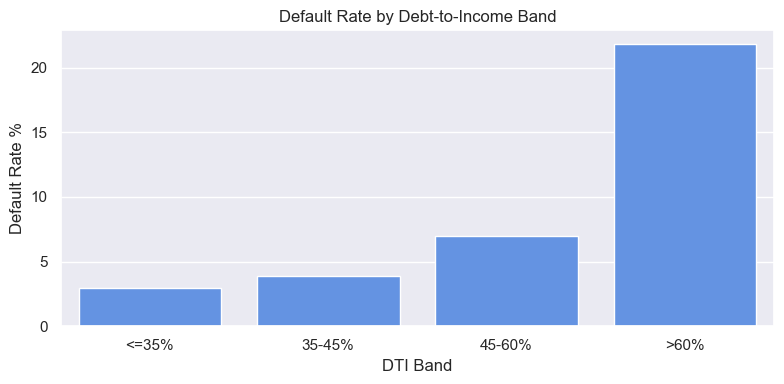

,dti_band,default_rate_percent
0,<=35%,2.93
1,35-45%,3.86
2,45-60%,6.97
3,>60%,21.78


In [20]:
# Quick visual check: default rate by DTI band
fig, ax = plt.subplots(figsize=(8, 4))
default_by_dti = (
    loan_analysis.groupby("dti_band", observed=False)["default_flag"]
    .mean()
    .mul(100)
    .reset_index(name="default_rate_percent")
)
sns.barplot(data=default_by_dti, x="dti_band", y="default_rate_percent", ax=ax, color="#4f8ef7")
ax.set_title("Default Rate by Debt-to-Income Band")
ax.set_xlabel("DTI Band")
ax.set_ylabel("Default Rate %")
fig.tight_layout()
fig.savefig(figures_dir / "data_quality" / "default_rate_by_dti_band.png", dpi=160, bbox_inches="tight")
plt.show()

default_by_dti


### Portfolio Quality Result

The prepared data has clear lending signals: default rate, total exposure, expected loss, and DTI-based risk differences. This makes it ready for deeper customer and loan-risk analysis.



## 12. Create Data Dictionary

The data dictionary explains the final fields so the cleaned datasets are easier to read later.



In [21]:
column_descriptions = {
    "customer_id": "Unique customer identifier.",
    "customer_name": "Synthetic customer name.",
    "age": "Customer age in years.",
    "gender": "Customer gender.",
    "nationality": "Customer nationality.",
    "occupation": "Customer occupation or business category.",
    "employment_status": "Employment status.",
    "banking_relationship": "Customer relationship segment such as Retail, Private Bank, Commercial, or Institutional.",
    "loyalty_classification": "Customer loyalty tier.",
    "investment_advisor": "Assigned advisor or relationship team.",
    "annual_income": "Estimated yearly customer income.",
    "total_deposit_balance": "Combined deposit, checking, and savings balance.",
    "loan_id": "Unique loan identifier.",
    "loan_type": "Type of loan product.",
    "loan_amount": "Loan principal amount.",
    "interest_rate": "Annual loan interest rate.",
    "collateral_type": "Collateral category for the loan.",
    "credit_score": "Borrower credit score.",
    "debt_to_income_ratio": "Debt payment burden relative to income.",
    "loan_to_value_ratio": "Loan amount compared with collateral value.",
    "missed_payments_12m": "Missed payments in the last 12 months.",
    "days_past_due": "Current overdue days.",
    "repayment_status": "Current repayment status.",
    "default_flag": "1 if defaulted, otherwise 0.",
    "risk_band": "Risk category: Low, Medium, or High.",
    "expected_loss_amount": "Estimated loss amount based on risk and exposure.",
}

data_dictionary = pd.DataFrame({
    "column": loan_analysis.columns,
    "dtype": [str(loan_analysis[column].dtype) for column in loan_analysis.columns],
    "missing_count": [int(loan_analysis[column].isna().sum()) for column in loan_analysis.columns],
    "description": [column_descriptions.get(column, "Engineered or supporting analysis field.") for column in loan_analysis.columns],
})

data_dictionary.head(20)


,column,dtype,missing_count,description
0,loan_id,object,0,Unique loan identifier.
1,customer_id,object,0,Unique customer identifier.
2,loan_type,category,0,Type of loan product.
3,loan_amount,float64,0,Loan principal amount.
4,loan_term_months,int64,0,Engineered or supporting analysis field.
5,interest_rate,float64,0,Annual loan interest rate.
6,loan_start_date,datetime64[ns],0,Engineered or supporting analysis field.
7,collateral_type,category,0,Collateral category for the loan.
8,collateral_value,float64,0,Engineered or supporting analysis field.
9,monthly_loan_payment,float64,0,Engineered or supporting analysis field.


### Data Dictionary Result

The data dictionary explains the final loan-level dataset. It makes each column easier to understand when using the cleaned data later.



## 13. Export Clean Data and Report Tables


In [22]:
# Export processed datasets.
customer_profile.to_csv(processed_dir / "banking_customer_profiles_clean.csv", index=False)
loan_analysis.to_csv(processed_dir / "banking_customer_loan_analytics_clean.csv", index=False)

# Keep this compatibility output for older project references.
loan_analysis.to_csv(processed_dir / "banking_customers_clean.csv", index=False)

# Export report tables.
raw_file_summary.to_csv(tables_dir / "raw_file_summary.csv", index=False)
raw_missing_summary.to_csv(tables_dir / "raw_missing_summary.csv", index=False)
raw_category_examples.to_csv(tables_dir / "raw_category_examples.csv", index=False)
raw_vs_clean_missing.to_csv(tables_dir / "raw_vs_clean_missing_summary.csv", index=False)
cleaning_actions.to_csv(tables_dir / "cleaning_actions_summary.csv", index=False)
validation_checks.to_csv(tables_dir / "relationship_validation_summary.csv", index=False)
missing_summary.reset_index(names="column").to_csv(tables_dir / "missing_value_summary.csv", index=False)
duplicate_summary.to_csv(tables_dir / "duplicate_summary.csv", index=False)
range_checks.to_csv(tables_dir / "range_validation_summary.csv", index=False)
outlier_summary.to_csv(tables_dir / "outlier_summary.csv", index=False)
quality_insight_summary.to_csv(tables_dir / "data_quality_summary.csv", index=False)
data_dictionary.to_csv(tables_dir / "data_dictionary.csv", index=False)

export_summary = pd.DataFrame([
    {"output": "banking_customer_profiles_clean.csv", "purpose": "Customer and segment EDA"},
    {"output": "banking_customer_loan_analytics_clean.csv", "purpose": "Loan exposure and risk EDA"},
    {"output": "data_dictionary.csv", "purpose": "Column documentation"},
    {"output": "data_quality_summary.csv", "purpose": "High-level quality and portfolio result summary"},
])
export_summary


,output,purpose
0,banking_customer_profiles_clean.csv,Customer and segment EDA
1,banking_customer_loan_analytics_clean.csv,Loan exposure and risk EDA
2,data_dictionary.csv,Column documentation
3,data_quality_summary.csv,High-level quality and portfolio result summary


### Saved Outputs

The clean datasets and supporting summary files were saved successfully. The next parts can use these outputs directly.



## 14. Final Summary

I started with four raw files: customers, financial profile, loans, and loan risk. The goal was to clean them, check their quality, and create final datasets that can be used for customer and lending-risk analysis.

### Raw Data Issues Found

The raw data had missing values in important columns:

- `annual_income`: 225 missing values
- `occupation`: 150 missing values
- `employment_status`: 120 missing values
- `credit_utilization_ratio`: 180 missing values
- `savings_balance`: 90 missing values
- `checking_balance`: 60 missing values
- `interest_rate`: 95 missing values
- `credit_score`: 214 missing values
- `debt_to_income_ratio`: 119 missing values

The raw data also had messy category labels because some values had extra spaces or different casing:

- `commercial` and ` Commercial `
- `retail` and ` RETAIL `
- `paid off` and ` Paid Off `
- `HIGH` and ` High `

### Cleaning Done

I cleaned the columns needed for analysis and future modelling:

- fixed extra spaces and casing in text columns
- filled missing `annual_income` using monthly income or relationship median
- filled missing `occupation` and `employment_status` as `Unknown`
- filled missing checking and savings balances using median values
- recalculated `credit_utilization_ratio` from card balance and card limit
- filled missing `interest_rate` using loan-type median
- filled missing `credit_score` and `debt_to_income_ratio` using risk-band median

I did not force-fill `collateral_type`, `loan_to_value_ratio`, and `ltv_band` because these are mainly missing for unsecured loans. In those cases, collateral and LTV are not applicable.

### Duplicate and Relationship Checks

After cleaning, I checked IDs and joins between the files.

Results:

- duplicate customer IDs: 0
- duplicate loan IDs: 0
- exact duplicate customer rows: 0
- exact duplicate loan rows: 0
- every financial profile matched a valid customer
- every loan matched a valid customer
- every loan had a matching risk record

The four files joined correctly using `customer_id` and `loan_id`.

### Range Checks

All important range checks passed:

- age is between 18 and 80
- annual income is positive
- loan amount is positive
- credit score is between 300 and 850
- `default_flag` contains only 0 and 1

### Missing Values After Cleaning

After cleaning, the model-important missing values became 0.

Remaining missing values:

- `ltv_band`: 3,324 missing values
- `loan_to_value_ratio`: 3,324 missing values

These remaining missing values are expected because unsecured loans do not have collateral or LTV.

### Outlier Check

I used IQR and boxplots to check outliers.

Outliers found:

- `annual_income`: 494 outliers, 4.15%
- `total_deposit_balance`: 676 outliers, 5.68%
- `loan_amount`: 548 outliers, 4.60%
- `credit_score`: 73 outliers, 0.61%
- `debt_to_income_ratio`: 140 outliers, 1.18%
- `expected_loss_amount`: 1,376 outliers, 11.55%

I kept these outliers because they can be real in banking data. High-income customers, large deposits, large loans, and high expected-loss loans are important for portfolio-risk analysis.

### Final Prepared Data

Final cleaned datasets:

- customer-level dataset: 15,000 customers
- loan-level dataset: 11,911 loan records

Important final numbers:

- customers with loans: 10,279
- customers without loans: 4,721
- overall default rate: 12.41%
- total loan exposure: INR 2460.72 crore
- total expected loss: INR 199.17 crore
- highest DTI band default rate: 21.78%
- high-risk band default rate: 53.82%

### What This Shows

The raw data had realistic quality issues, but after cleaning it became reliable enough for analysis. The final data now has customer details, financial position, loan information, repayment status, default flag, and risk indicators. It can be used for customer segment analysis, lending-risk analysis, and a default prediction model.
